# 7. ESG Integration and Statistical Analysis

## 7.1 LSEG ESG Data Extraction

LSEG ESG dashboard reports are used as the external measure of corporate ESG performance.

For each company, four variables are extracted from the LSEG dashboard:

- Overall ESG Score
- Environmental Score
- Social Score
- Governance Score

The overall ESG score serves as the primary dependent variable for the subsequent statistical analyses, while the three pillar scores are retained for supplementary analyses.

Because the dashboard reports are exported as image-based PDF documents, a structured computer-assisted extraction and validation procedure is adopted to ensure accuracy and reproducibility.

## 7.2 Locate the ESG Reports

In [2]:
from pathlib import Path
import pandas as pd

PROJECT_DIR = Path(
    r"C:\Users\techi\Desktop\Greenwashing_Disssertation"
)

LSEG_ESG_DIR = (
    PROJECT_DIR /
    "Data" /
    "LSEG-ESG_Data"
)

OUTPUT_DIR = (
    PROJECT_DIR /
    "Data" /
    "ESG_Outputs"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

pdf_files = sorted(
    LSEG_ESG_DIR.glob("*.pdf")
)

print("Folder exists:", LSEG_ESG_DIR.exists())
print("Number of PDF reports:", len(pdf_files))

print("\nFirst five reports:")

for pdf in pdf_files[:5]:
    print(pdf.name)

Folder exists: True
Number of PDF reports: 25

First five reports:
Anglo American PLC LSEG-ESG.pdf
AstraZeneca PLC LSEG-ESG.pdf
BAE Systems PLC LSEG-ESG.pdf
Barclays PLC LSEG-ESG.pdf
BP PLC LSEG-ESG.pdf


## 7.3 Preview an LSEG ESG Dashboard

The first page of each LSEG dashboard contains the overall ESG score and the Environmental, Social and Governance pillar scores. The page is rendered inside the notebook to support accurate manual transcription.

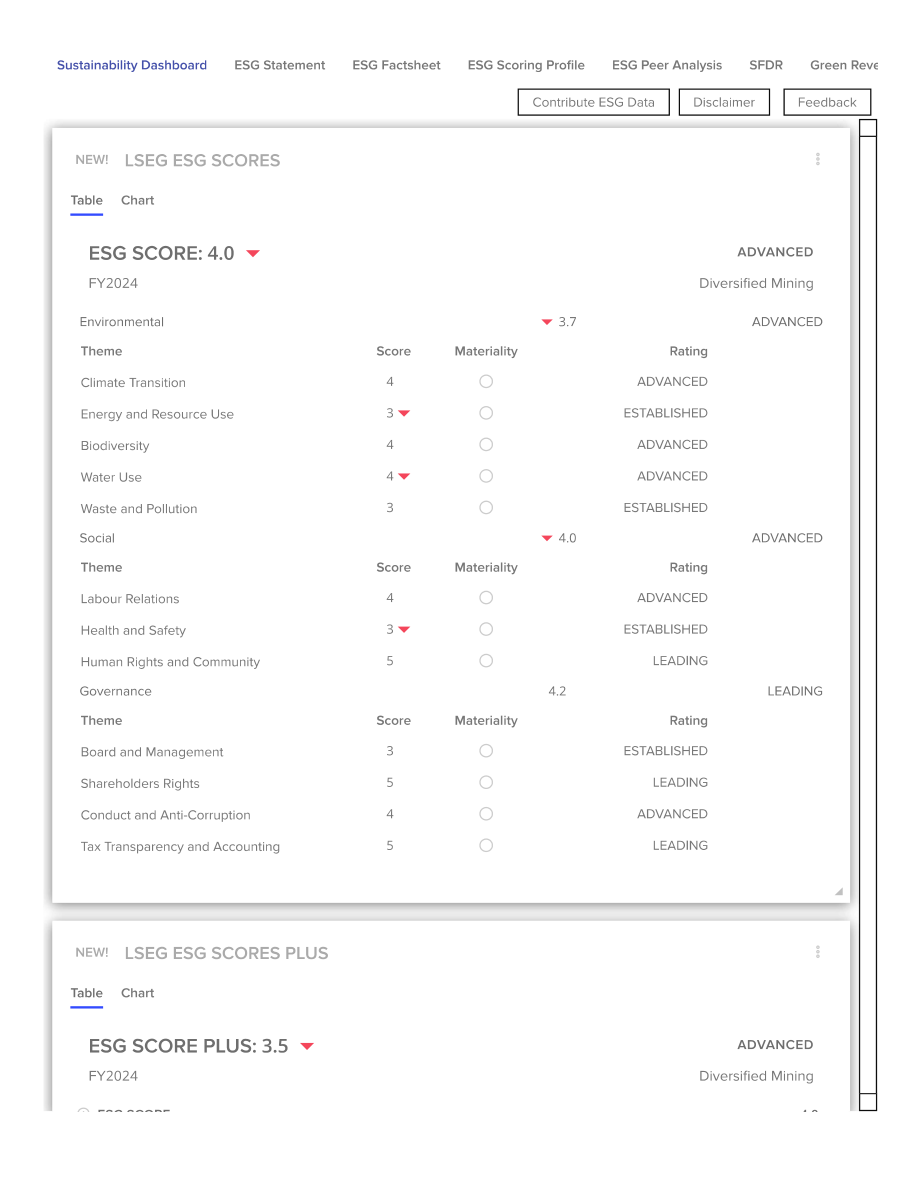

File: Anglo American PLC LSEG-ESG.pdf
Pages: 2


In [5]:
import fitz
from IPython.display import Image, display

test_pdf_path = pdf_files[0]

document = fitz.open(test_pdf_path)

page = document.load_page(1)  # Page 2

page_image = page.get_pixmap(
    matrix=fitz.Matrix(1.5, 1.5),
    alpha=False
)

display(
    Image(
        data=page_image.tobytes("png")
    )
)

print("File:", test_pdf_path.name)
print("Pages:", len(document))

document.close()

## 7.4 Guided Score Entry for All Companies

This loop displays Page 2 of each PDF and asks you to enter the four scores.

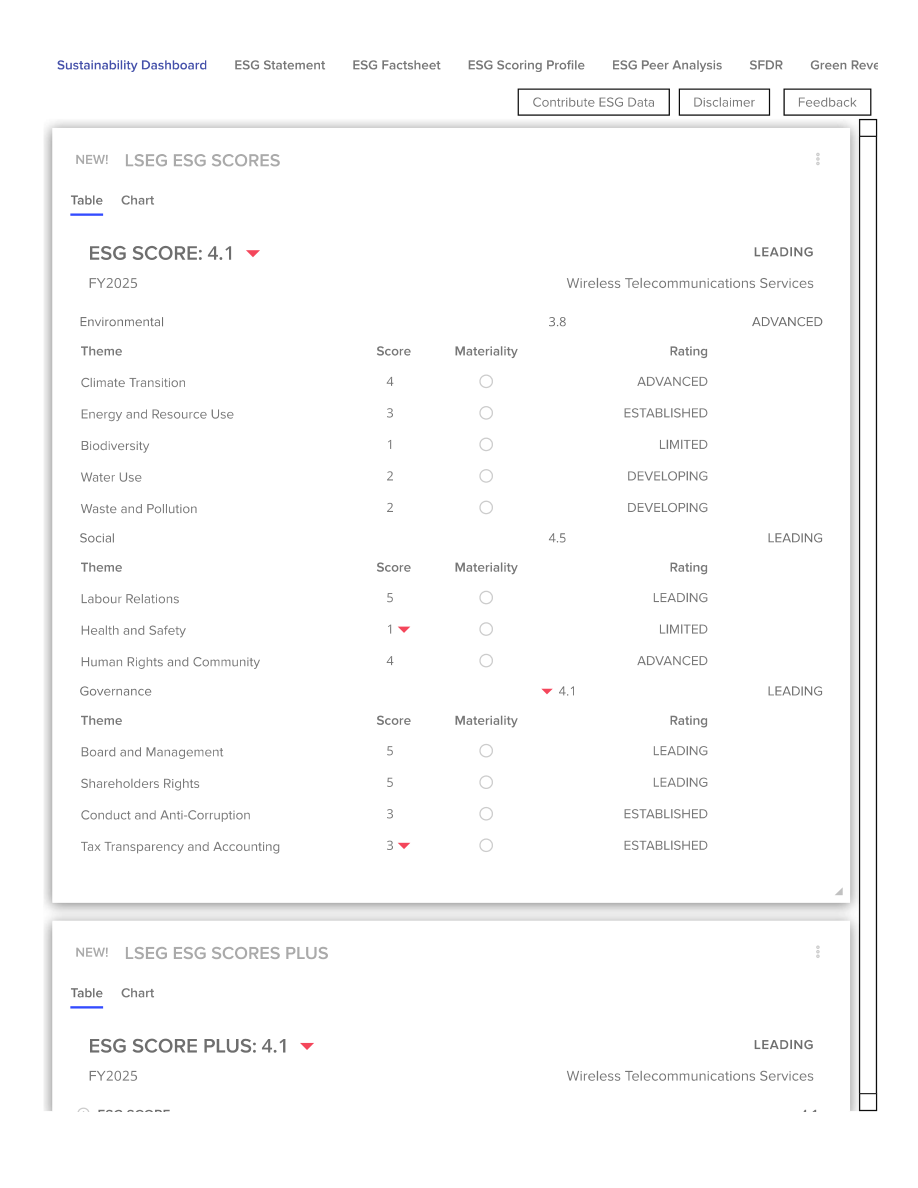

Company 25 of 25
Company: Vodafone PLC
File: Vodafone PLC LSEG-ESG.pdf


Overall ESG Score:  4.1
Environmental Score:  3.8
Social Score:  4.5
Governance Score:  4.1



Record saved.


Press Enter to continue to the next company... 


In [6]:
### from IPython.display import clear_output
import pandas as pd
import fitz

esg_records = []

for index, pdf_path in enumerate(pdf_files, start=1):

    clear_output(wait=True)

    document = fitz.open(pdf_path)
    page = document.load_page(1)

    page_image = page.get_pixmap(
        matrix=fitz.Matrix(1.5, 1.5),
        alpha=False
    )

    display(
        Image(
            data=page_image.tobytes("png")
        )
    )

    document.close()

    company_name = (
        pdf_path.stem
        .replace(" LSEG-ESG", "")
        .strip()
    )

    print(f"Company {index} of {len(pdf_files)}")
    print("Company:", company_name)
    print("File:", pdf_path.name)

    overall_score = float(
        input("Overall ESG Score: ")
    )

    environmental_score = float(
        input("Environmental Score: ")
    )

    social_score = float(
        input("Social Score: ")
    )

    governance_score = float(
        input("Governance Score: ")
    )

    esg_records.append({
        "Company_Name": company_name,
        "PDF_File": pdf_path.name,
        "LSEG_ESG_Score": overall_score,
        "Environmental_Score": environmental_score,
        "Social_Score": social_score,
        "Governance_Score": governance_score
    })

    print("\nRecord saved.")
    input("Press Enter to continue to the next company...")

In [8]:
# Display recorded values 

lseg_esg_df = pd.DataFrame(esg_records)

print("Companies recorded:", len(lseg_esg_df))

display(lseg_esg_df)

Companies recorded: 25


,Company_Name,PDF_File,LSEG_ESG_Score,Environmental_Score,Social_Score,Governance_Score
0,Anglo American PLC,Anglo American PLC LSEG-ESG.pdf,4.0,3.7,4.0,4.2
1,AstraZeneca PLC,AstraZeneca PLC LSEG-ESG.pdf,3.5,3.8,2.6,4.1
2,BAE Systems PLC,BAE Systems PLC LSEG-ESG.pdf,3.1,2.6,2.9,3.7
3,Barclays PLC,Barclays PLC LSEG-ESG.pdf,4.0,4.5,3.5,4.0
4,BP PLC,BP PLC LSEG-ESG.pdf,4.0,3.9,3.9,4.2
5,British American Tobacco PLC,British American Tobacco PLC LSEG-ESG.pdf,4.4,4.2,4.6,4.6
6,Bunzl PLC,Bunzl PLC LSEG-ESG.pdf,2.7,2.5,2.3,3.4
7,Compass Group PLC,Compass Group PLC LSEG-ESG.pdf,3.1,2.8,2.6,4.0
8,Computacenter PLC,Computacenter PLC LSEG-ESG.pdf,3.4,3.5,2.3,3.9
9,Diageo PLC,Diageo PLC LSEG-ESG.pdf,4.1,4.1,3.7,4.4


## 7.5 Validate the Recorded ESG Scores

The recorded dataset is checked for completeness, duplicate companies and values outside the valid LSEG score range of 1–5

In [9]:
# Basic dataset checks

print("Rows recorded:", len(lseg_esg_df))
print("Unique companies:", lseg_esg_df["Company_Name"].nunique())
print("Duplicate companies:", lseg_esg_df["Company_Name"].duplicated().sum())

score_columns = [
    "LSEG_ESG_Score",
    "Environmental_Score",
    "Social_Score",
    "Governance_Score"
]

print("\nMissing values by column:")
print(lseg_esg_df[score_columns].isna().sum())

Rows recorded: 25
Unique companies: 25
Duplicate companies: 0

Missing values by column:
LSEG_ESG_Score         0
Environmental_Score    0
Social_Score           0
Governance_Score       0
dtype: int64


In [10]:
# Identify scores outside the valid 1–5 range

invalid_score_rows = lseg_esg_df[
    ~lseg_esg_df[score_columns]
    .apply(lambda column: column.between(1, 5))
    .all(axis=1)
]

print("Rows containing invalid scores:", len(invalid_score_rows))

if not invalid_score_rows.empty:
    display(
        invalid_score_rows[
            ["Company_Name"] + score_columns
        ]
    )

Rows containing invalid scores: 0


In [20]:
# final assertions of LSEG-ESG scores for all 25 companies 

assert len(lseg_esg_df) == 25, (
    "The dataset should contain exactly 25 companies."
)

assert lseg_esg_df["Company_Name"].nunique() == 25, (
    "Company names are duplicated or missing."
)

assert lseg_esg_df[score_columns].notna().all().all(), (
    "Some ESG scores are missing."
)

assert (
    lseg_esg_df[score_columns]
    .apply(lambda column: column.between(1, 5))
    .all()
    .all()
), "At least one ESG score falls outside the valid 1–5 range."

print("LSEG ESG score validation completed successfully.")

LSEG ESG score validation completed successfully.


## 7.6 Add Company Identifiers

The ESG dataset must use the same Company_ID values as the LDA and FinBERT outputs so the datasets can be merged accurately.

In [19]:
# Create a mapping between company names and Company_IDs

company_id_map = {

    # C01–C05
    "Vodafone Group PLC": "C01",
    "Vodafone PLC": "C01",

    "British American Tobacco PLC": "C02",

    "Diageo PLC": "C03",

    "Segro PLC": "C04",
    "SEGRO PLC": "C04",

    "Bunzl PLC": "C05",

    # C06–C10
    "GSK PLC": "C06",

    "Unilever PLC": "C07",

    "Tesco PLC": "C08",

    "BAE Systems PLC": "C09",

    "Shell PLC": "C10",
    "SHELL PLC": "C10",

    # C11–C15
    "HSBC Holdings PLC": "C11",
    "HSBC PLC": "C11",

    "AstraZeneca PLC": "C12",

    "BP PLC": "C13",

    "Legal & General Group PLC": "C14",
    "Legal & General PLC": "C14",

    "Lloyds Banking Group PLC": "C15",

    # C16–C20
    "Barclays PLC": "C16",

    "RELX PLC": "C17",

    "Computacenter PLC": "C18",

    "Glencore PLC": "C19",

    "Compass Group PLC": "C20",

    # C21–C25
    "Rolls-Royce Holdings PLC": "C21",

    "National Grid PLC": "C22",

    "SSE PLC": "C23",

    "Anglo American PLC": "C24",

    "Rio Tinto PLC": "C25"
}

# Map Company_IDs

lseg_esg_df["Company_ID"] = (
    lseg_esg_df["Company_Name"]
    .map(company_id_map)
)

# Display any unmatched companies

unmatched = lseg_esg_df[
    lseg_esg_df["Company_ID"].isna()
]

print("Companies without a matched ID:",
      len(unmatched))

if len(unmatched) > 0:
    display(
        unmatched[
            ["Company_Name", "PDF_File"]
        ]
    )

# Sort by Company_ID

lseg_esg_df = (
    lseg_esg_df
    .sort_values("Company_ID")
    .reset_index(drop=True)
)

display(
    lseg_esg_df[
        [
            "Company_ID",
            "Company_Name",
            "LSEG_ESG_Score",
            "Environmental_Score",
            "Social_Score",
            "Governance_Score"
        ]
    ]
)

# Final validation

assert lseg_esg_df["Company_ID"].notna().all(), \
    "Some companies could not be matched."

assert lseg_esg_df["Company_ID"].nunique() == 25, \
    "Duplicate or missing Company_IDs."

print("\n✓ All 25 companies matched successfully.")

Companies without a matched ID: 0


,Company_ID,Company_Name,LSEG_ESG_Score,Environmental_Score,Social_Score,Governance_Score
0,C01,Vodafone PLC,4.1,3.8,4.5,4.1
1,C02,British American Tobacco PLC,4.4,4.2,4.6,4.6
2,C03,Diageo PLC,4.1,4.1,3.7,4.4
3,C04,SEGRO PLC,3.2,3.3,3.0,3.3
4,C05,Bunzl PLC,2.7,2.5,2.3,3.4
5,C06,GSK PLC,4.3,4.4,4.1,4.5
6,C07,Unilever PLC,3.9,3.7,3.8,4.5
7,C08,Tesco PLC,3.4,2.8,2.9,4.8
8,C09,BAE Systems PLC,3.1,2.6,2.9,3.7
9,C10,SHELL PLC,4.1,3.6,4.3,4.3



✓ All 25 companies matched successfully.


## 7.7 Load and Validate the Company-Level NLP Outputs

The validated company-level LDA and FinBERT outputs are imported and checked before merging with the LSEG ESG scores.

In [21]:
# Define input paths

LDA_COMPANY_PATH = (
    PROJECT_DIR
    / "Data"
    / "LDA_Outputs"
    / "Company_Level_LDA_Topic_Distribution.csv"
)

FINBERT_COMPANY_PATH = (
    PROJECT_DIR
    / "Data"
    / "Sentiment_Outputs"
    / "Company_Level_FinBERT_Sentiment.csv"
)


# Load datasets

lda_company_df = pd.read_csv(
    LDA_COMPANY_PATH
)

finbert_company_df = pd.read_csv(
    FINBERT_COMPANY_PATH
)


print("LDA dataset shape:", lda_company_df.shape)
print("FinBERT dataset shape:", finbert_company_df.shape)

print(
    "LDA companies:",
    lda_company_df["Company_ID"].nunique()
)

print(
    "FinBERT companies:",
    finbert_company_df["Company_ID"].nunique()
)

LDA dataset shape: (25, 15)
FinBERT dataset shape: (25, 5)
LDA companies: 25
FinBERT companies: 25


In [22]:
# Validate the identifiers 

assert len(lda_company_df) == 25, (
    "The LDA dataset should contain 25 companies."
)

assert len(finbert_company_df) == 25, (
    "The FinBERT dataset should contain 25 companies."
)

assert lda_company_df["Company_ID"].is_unique, (
    "Duplicate Company_ID values found in the LDA dataset."
)

assert finbert_company_df["Company_ID"].is_unique, (
    "Duplicate Company_ID values found in the FinBERT dataset."
)

assert set(lda_company_df["Company_ID"]) == set(
    finbert_company_df["Company_ID"]
), "The LDA and FinBERT company identifiers do not match."

print("Company-level NLP datasets validated successfully.")

Company-level NLP datasets validated successfully.


## 7.8 Merge LSEG ESG Scores with LDA Topic Profiles

The company-level topic distributions are merged with the validated LSEG ESG scores using Company_ID.

In [23]:
esg_lda_df = lseg_esg_df.merge(
    lda_company_df,
    on="Company_ID",
    how="inner",
    validate="one_to_one"
)

print("ESG–LDA merged shape:", esg_lda_df.shape)
print(
    "Companies represented:",
    esg_lda_df["Company_ID"].nunique()
)

ESG–LDA merged shape: (25, 21)
Companies represented: 25


In [24]:
# Validate the merge

assert len(esg_lda_df) == 25, (
    "The ESG–LDA merge did not retain all 25 companies."
)

print("LSEG ESG and LDA datasets merged successfully.")

LSEG ESG and LDA datasets merged successfully.


## 7.9 Merge FinBERT Sentiment Results

The company-level FinBERT measures are added to create one integrated analytical dataset.

In [25]:
final_analysis_df = esg_lda_df.merge(
    finbert_company_df,
    on="Company_ID",
    how="inner",
    validate="one_to_one"
)

print("Final analytical dataset shape:", final_analysis_df.shape)
print(
    "Companies represented:",
    final_analysis_df["Company_ID"].nunique()
)

Final analytical dataset shape: (25, 25)
Companies represented: 25


In [26]:
# Validate the final merge 

assert len(final_analysis_df) == 25, (
    "The final merge did not retain all 25 companies."
)

assert final_analysis_df["Company_ID"].is_unique, (
    "Duplicate companies exist in the final dataset."
)

print("Final analytical dataset merged successfully.")

Final analytical dataset merged successfully.


## 7.10 Inspect the Final Analytical Dataset

In [27]:
print(final_analysis_df.columns.tolist())

display(
    final_analysis_df.head()
)

['Company_Name', 'PDF_File', 'LSEG_ESG_Score', 'Environmental_Score', 'Social_Score', 'Governance_Score', 'Company_ID', 'Climate Risk and Materiality Assessment (%)', 'Community Investment and Social Development (%)', 'Human Rights and Responsible Supply Chains (%)', 'Occupational Health and Safety (%)', 'External Assurance and Verification (%)', 'Workforce Development, Inclusion and Wellbeing (%)', 'Sustainable Finance and Transition Investment (%)', 'Sustainability Governance and Oversight (%)', 'Carbon Reduction and Net-Zero Transition (%)', 'Renewable Energy and Energy Systems (%)', 'ESG Reporting Standards and Material Disclosures (%)', 'Biodiversity, Water and Natural Capital (%)', 'Emissions Measurement and Reporting Methodology (%)', 'Resource Use, Waste and Operational Efficiency (%)', 'Mean_Positive', 'Mean_Negative', 'Mean_Neutral', 'Mean_Sentiment_Score']


,Company_Name,PDF_File,LSEG_ESG_Score,Environmental_Score,Social_Score,Governance_Score,Company_ID,Climate Risk and Materiality Assessment (%),Community Investment and Social Development (%),Human Rights and Responsible Supply Chains (%),...,Carbon Reduction and Net-Zero Transition (%),Renewable Energy and Energy Systems (%),ESG Reporting Standards and Material Disclosures (%),"Biodiversity, Water and Natural Capital (%)",Emissions Measurement and Reporting Methodology (%),"Resource Use, Waste and Operational Efficiency (%)",Mean_Positive,Mean_Negative,Mean_Neutral,Mean_Sentiment_Score
0,Vodafone PLC,Vodafone PLC LSEG-ESG.pdf,4.1,3.8,4.5,4.1,C01,6.588273,19.175167,11.540411,...,7.842286,4.585160,7.789691,1.072713,5.688142,0.937126,0.223099,0.045257,0.731643,0.177842
1,British American Tobacco PLC,British American Tobacco PLC LSEG-ESG.pdf,4.4,4.2,4.6,4.6,C02,11.876636,2.214393,9.278516,...,7.968350,2.305175,4.160328,3.374055,6.279193,33.712246,0.205822,0.055724,0.738454,0.150098
2,Diageo PLC,Diageo PLC LSEG-ESG.pdf,4.1,4.1,3.7,4.4,C03,11.075358,7.753166,16.329952,...,18.714323,2.742893,14.120643,6.384090,2.232924,6.265318,0.084950,0.066837,0.848213,0.018113
3,SEGRO PLC,SEGRO PLC LSEG-ESG.pdf,3.2,3.3,3.0,3.3,C04,7.812285,1.872897,1.314305,...,17.047192,2.719862,3.338183,1.182310,6.935804,2.779324,0.303319,0.040389,0.656292,0.262930
4,Bunzl PLC,Bunzl PLC LSEG-ESG.pdf,2.7,2.5,2.3,3.4,C05,2.551131,2.092666,13.016737,...,4.877009,9.407327,1.157207,0.864639,15.923552,1.938037,0.442126,0.059699,0.498175,0.382426


## 7.11 Final Dataset Validation

The integrated company-level dataset was checked for completeness, uniqueness and missing values before statistical analysis.

The final dataset contains one observation for each of the 25 sampled FTSE 100 companies and combines LSEG ESG performance, LDA topic distributions and FinBERT sentiment measures.

In [28]:
# Validate final analytical dataset

assert len(final_analysis_df) == 25, (
    "The final dataset should contain 25 companies."
)

assert final_analysis_df["Company_ID"].is_unique, (
    "Duplicate Company_ID values exist."
)

print("Missing values by column:")

missing_values = (
    final_analysis_df
    .isna()
    .sum()
)

print(
    missing_values[
        missing_values > 0
    ]
)

assert not missing_values.any(), (
    "The final analytical dataset contains missing values."
)

print("\nFinal dataset validation completed successfully.")
print("Final shape:", final_analysis_df.shape)

Missing values by column:
Series([], dtype: int64)

Final dataset validation completed successfully.
Final shape: (25, 25)


In [29]:
# save the final dataset 

FINAL_OUTPUT_DIR = (
    PROJECT_DIR
    / "Data"
    / "Final_Datasets"
)

FINAL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

final_dataset_path = (
    FINAL_OUTPUT_DIR
    / "Final_Greenwashing_Analytical_Dataset.csv"
)

final_analysis_df.to_csv(
    final_dataset_path,
    index=False,
    encoding="utf-8-sig"
)

print("Final analytical dataset saved to:")
print(final_dataset_path)

Final analytical dataset saved to:
C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\Final_Datasets\Final_Greenwashing_Analytical_Dataset.csv


## Visualise Overall LSEG ESG Scores

A horizontal bar chart is used to compare overall LSEG ESG scores across the 25 sampled companies. The visualisation highlights cross-company variation in ESG performance prior to examining relationships with disclosure topics and sentiment.

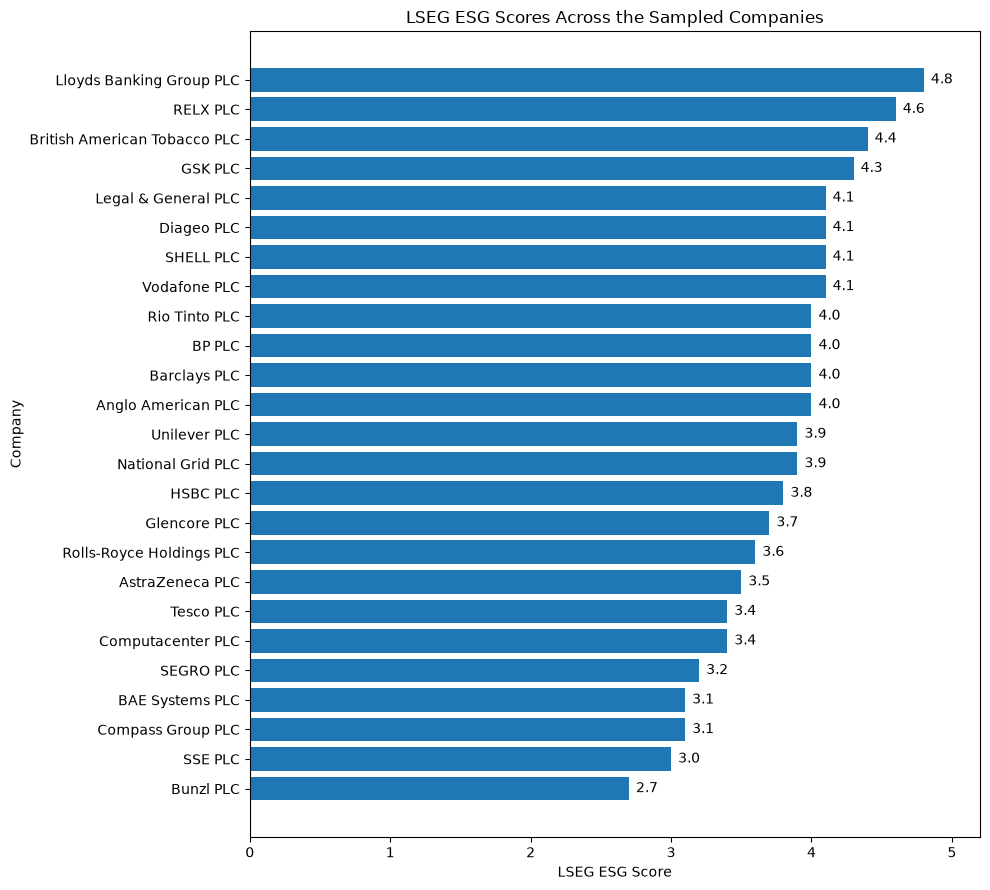

In [62]:
import matplotlib.pyplot as plt

# Prepare company-level ESG ranking

esg_plot_df = (
    final_analysis_df[
        [
            "Company_Name",
            "LSEG_ESG_Score"
        ]
    ]
    .sort_values(
        "LSEG_ESG_Score",
        ascending=True
    )
)

# Create horizontal bar chart

plt.figure(figsize=(10, 9))

bars = plt.barh(
    esg_plot_df["Company_Name"],
    esg_plot_df["LSEG_ESG_Score"]
)

plt.xlabel("LSEG ESG Score")
plt.ylabel("Company")

plt.title(
    "LSEG ESG Scores Across the Sampled Companies"
)

plt.xlim(0, 5.2)

# Add score labels

for bar, value in zip(
    bars,
    esg_plot_df["LSEG_ESG_Score"]
):
    plt.text(
        value + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center"
    )

plt.tight_layout()

plt.show()

In [64]:
# save the horizontal barchart 

figure_output_dir = Path(
    r"C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\Final_Datasets"
)

figure_output_dir.mkdir(
    parents=True,
    exist_ok=True
)

esg_figure_path = (
    figure_output_dir
    / "LSEG_ESG_Scores_Across_Companies.png"
)

plt.figure(figsize=(10, 9))

bars = plt.barh(
    esg_plot_df["Company_Name"],
    esg_plot_df["LSEG_ESG_Score"]
)

plt.xlabel("LSEG ESG Score")
plt.ylabel("Company")

plt.title(
    "LSEG ESG Scores Across the Sampled Companies"
)

plt.xlim(0, 5.2)

for bar, value in zip(
    bars,
    esg_plot_df["LSEG_ESG_Score"]
):
    plt.text(
        value + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    esg_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Figure saved to:")
print(esg_figure_path)

Figure saved to:
C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\Final_Datasets\LSEG_ESG_Scores_Across_Companies.png


## 7.12 Descriptive Statistics

The statistical analysis begins with a summary of the LSEG ESG scores, FinBERT sentiment measures and company-level LDA topic proportions.

Descriptive statistics are used to assess central tendency, variation and the range of values before correlation and regression analysis.

In [30]:
# Define the main variable groups

esg_variables = [
    "LSEG_ESG_Score",
    "Environmental_Score",
    "Social_Score",
    "Governance_Score"
]

sentiment_variables = [
    "Mean_Positive",
    "Mean_Negative",
    "Mean_Neutral",
    "Mean_Sentiment_Score"
]

topic_variables = [
    column
    for column in final_analysis_df.columns
    if column.endswith("(%)")
]

print("ESG variables:", len(esg_variables))
print("Sentiment variables:", len(sentiment_variables))
print("Topic variables:", len(topic_variables))

ESG variables: 4
Sentiment variables: 4
Topic variables: 14


In [31]:
# Produce the descriptive statistics table 

analysis_variables = (
    esg_variables
    + sentiment_variables
    + topic_variables
)

descriptive_statistics = (
    final_analysis_df[analysis_variables]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "Variable"})
)

descriptive_statistics = descriptive_statistics[
    [
        "Variable",
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
]

descriptive_statistics[
    [
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
] = descriptive_statistics[
    [
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
].round(3)

display(descriptive_statistics)

,Variable,count,mean,std,min,25%,50%,75%,max
0,LSEG_ESG_Score,25.0,3.792,0.518,2.700,3.400,3.900,4.100,4.800
1,Environmental_Score,25.0,3.620,0.609,2.500,3.300,3.600,4.000,4.800
2,Social_Score,25.0,3.516,0.784,2.300,2.900,3.700,4.100,5.000
3,Governance_Score,25.0,4.148,0.482,3.300,3.900,4.200,4.500,5.000
4,Mean_Positive,25.0,0.279,0.127,0.044,0.206,0.307,0.367,0.518
5,Mean_Negative,25.0,0.046,0.022,0.011,0.034,0.043,0.056,0.098
6,Mean_Neutral,25.0,0.675,0.118,0.470,0.587,0.655,0.758,0.861
7,Mean_Sentiment_Score,25.0,0.233,0.138,-0.054,0.150,0.263,0.349,0.506
8,Climate Risk and Materiality Assessment (%),25.0,9.538,8.955,1.381,3.806,7.652,11.610,42.735
9,Community Investment and Social Development (%),25.0,7.032,7.487,1.299,2.333,4.657,7.601,33.874


In [33]:
# validate descriptive statistics summary 

assert (
    descriptive_statistics["count"] == 25
).all(), "At least one analytical variable has fewer than 25 observations."

print("Descriptive statistics validated successfully.")

Descriptive statistics validated successfully.


In [34]:
# Save the table 

descriptive_output_path = (
    FINAL_OUTPUT_DIR
    / "Descriptive_Statistics.csv"
)

descriptive_statistics.to_csv(
    descriptive_output_path,
    index=False,
    encoding="utf-8-sig"
)

print("Descriptive statistics saved to:")
print(descriptive_output_path)

Descriptive statistics saved to:
C:\Users\techi\Desktop\Greenwashing_Disssertation\Data\Final_Datasets\Descriptive_Statistics.csv


## 7.13 Rank Companies by Overall ESG Score

This produces a simple inspection table for the primary dependent variable.

In [35]:
esg_ranking = (
    final_analysis_df[
        [
            "Company_ID",
            "Company_Name",
            "LSEG_ESG_Score",
            "Environmental_Score",
            "Social_Score",
            "Governance_Score"
        ]
    ]
    .sort_values(
        "LSEG_ESG_Score",
        ascending=False
    )
    .reset_index(drop=True)
)

esg_ranking.index = esg_ranking.index + 1
esg_ranking.index.name = "Rank"

display(esg_ranking)

,Company_ID,Company_Name,LSEG_ESG_Score,Environmental_Score,Social_Score,Governance_Score
Rank,,,,,,
1,C15,Lloyds Banking Group PLC,4.8,4.8,5.0,4.7
2,C17,RELX PLC,4.6,3.3,4.3,5.0
3,C02,British American Tobacco PLC,4.4,4.2,4.6,4.6
4,C06,GSK PLC,4.3,4.4,4.1,4.5
5,C01,Vodafone PLC,4.1,3.8,4.5,4.1
6,C14,Legal & General PLC,4.1,4.5,3.0,4.2
7,C10,SHELL PLC,4.1,3.6,4.3,4.3
8,C03,Diageo PLC,4.1,4.1,3.7,4.4
9,C13,BP PLC,4.0,3.9,3.9,4.2


In [37]:
 # save the ESG ranking table 

esg_ranking_path = (
    FINAL_OUTPUT_DIR
    / "Company_ESG_Ranking.csv"
)

esg_ranking.to_csv(
    esg_ranking_path,
    encoding="utf-8-sig"
)

print("ESG ranking saved successfully.")

ESG ranking saved successfully.


## 7.14 Correlation Analysis

Pearson correlation analysis is conducted to examine the linear relationships between LSEG ESG performance, disclosure sentiment and the company-level topic distributions.

The analysis is used to identify variables that exhibit meaningful associations with ESG performance and to inform the subsequent regression models.

In [38]:
# Variables included in the correlation analysis

correlation_variables = (
    esg_variables
    + ["Mean_Sentiment_Score"]
    + topic_variables
)

correlation_matrix = (
    final_analysis_df[
        correlation_variables
    ].corr(method="pearson")
)

display(
    correlation_matrix.round(3)
)

,LSEG_ESG_Score,Environmental_Score,Social_Score,Governance_Score,Mean_Sentiment_Score,Climate Risk and Materiality Assessment (%),Community Investment and Social Development (%),Human Rights and Responsible Supply Chains (%),Occupational Health and Safety (%),External Assurance and Verification (%),"Workforce Development, Inclusion and Wellbeing (%)",Sustainable Finance and Transition Investment (%),Sustainability Governance and Oversight (%),Carbon Reduction and Net-Zero Transition (%),Renewable Energy and Energy Systems (%),ESG Reporting Standards and Material Disclosures (%),"Biodiversity, Water and Natural Capital (%)",Emissions Measurement and Reporting Methodology (%),"Resource Use, Waste and Operational Efficiency (%)"
LSEG_ESG_Score,1.000,0.769,0.854,0.707,-0.483,0.249,0.174,-0.084,-0.361,0.011,-0.413,-0.081,-0.020,0.050,-0.170,0.521,-0.162,-0.037,0.314
Environmental_Score,0.769,1.000,0.600,0.339,-0.242,0.100,0.180,-0.232,-0.155,0.194,-0.266,0.033,-0.027,-0.094,-0.236,0.279,-0.214,-0.073,0.276
Social_Score,0.854,0.600,1.000,0.467,-0.523,0.479,0.287,-0.049,-0.400,-0.129,-0.578,-0.129,-0.100,0.080,-0.082,0.422,-0.132,-0.008,0.392
Governance_Score,0.707,0.339,0.467,1.000,-0.324,-0.136,-0.019,0.101,-0.299,0.087,-0.264,-0.029,-0.138,0.208,0.214,0.329,0.231,-0.249,0.267
Mean_Sentiment_Score,-0.483,-0.242,-0.523,-0.324,1.000,-0.539,-0.525,-0.110,0.263,0.381,0.546,0.502,-0.005,-0.309,0.008,-0.613,0.045,0.239,-0.435
Climate Risk and Materiality Assessment (%),0.249,0.100,0.479,-0.136,-0.539,1.000,0.389,-0.135,-0.178,-0.223,-0.363,-0.475,-0.041,-0.094,-0.239,0.395,-0.180,-0.054,0.168
Community Investment and Social Development (%),0.174,0.180,0.287,-0.019,-0.525,0.389,1.000,-0.140,0.024,-0.059,-0.287,-0.226,-0.378,-0.013,-0.111,0.076,-0.188,-0.450,0.220
Human Rights and Responsible Supply Chains (%),-0.084,-0.232,-0.049,0.101,-0.110,-0.135,-0.140,1.000,-0.393,-0.176,0.245,-0.298,-0.058,-0.158,0.101,0.253,0.427,-0.168,0.078
Occupational Health and Safety (%),-0.361,-0.155,-0.400,-0.299,0.263,-0.178,0.024,-0.393,1.000,0.019,0.456,0.043,-0.224,0.079,-0.136,-0.196,-0.102,-0.343,-0.183
External Assurance and Verification (%),0.011,0.194,-0.129,0.087,0.381,-0.223,-0.059,-0.176,0.019,1.000,-0.078,0.011,-0.311,-0.265,-0.037,-0.098,-0.111,-0.188,0.006


In [39]:
# save correlation matrix 

correlation_path = (
    FINAL_OUTPUT_DIR /
    "Correlation_Matrix.csv"
)

correlation_matrix.to_csv(
    correlation_path,
    encoding="utf-8-sig"
)

print("Correlation matrix saved.")

Correlation matrix saved.


## 7.15 Correlation Heatmap

A Pearson correlation heatmap is produced to visualise the relationships between ESG performance, disclosure sentiment and the company-level topic distributions.

The heatmap complements the correlation matrix by providing an intuitive visual representation of positive and negative associations between variables. It serves as an exploratory tool prior to regression modelling.

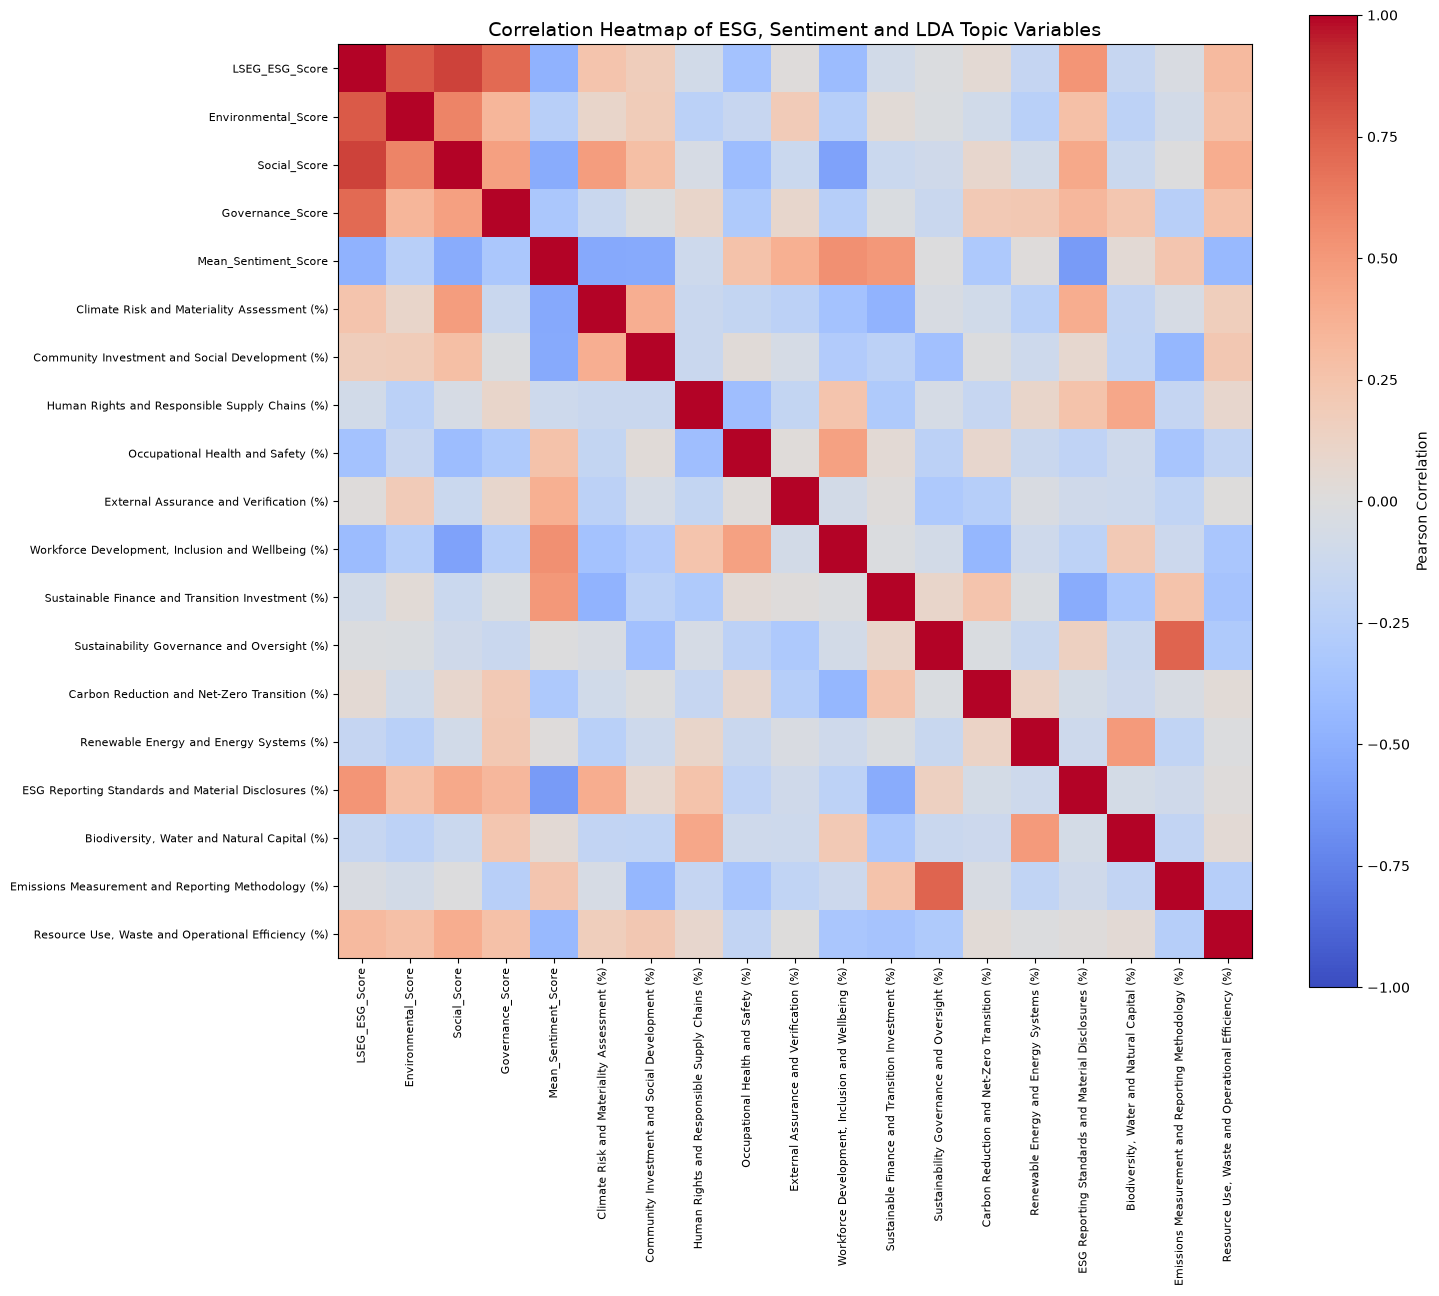

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure

plt.figure(figsize=(15, 13))

# Plot correlation matrix

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

# Add colour bar

plt.colorbar(label="Pearson Correlation")

# Tick labels

plt.xticks(
    np.arange(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90,
    fontsize=8
)

plt.yticks(
    np.arange(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    fontsize=8
)

plt.title(
    "Correlation Heatmap of ESG, Sentiment and LDA Topic Variables",
    fontsize=14
)

plt.tight_layout()

plt.show()

In [41]:
# save the correlation heatmap 

heatmap_path = (
    FINAL_OUTPUT_DIR /
    "Correlation_Heatmap.png"
)

plt.figure(figsize=(15, 13))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Pearson Correlation")

plt.xticks(
    np.arange(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90,
    fontsize=8
)

plt.yticks(
    np.arange(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    fontsize=8
)

plt.title(
    "Correlation Heatmap of ESG, Sentiment and LDA Topic Variables",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    heatmap_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Correlation heatmap saved successfully.")

Correlation heatmap saved successfully.


In [65]:
esg_correlations = (
    correlation_matrix["LSEG_ESG_Score"]
    .drop("LSEG_ESG_Score")
    .sort_values(ascending=False)
)

print(
    esg_correlations.round(3)
)

Social_Score                                            0.854
Environmental_Score                                     0.769
Governance_Score                                        0.707
ESG Reporting Standards and Material Disclosures (%)    0.521
Resource Use, Waste and Operational Efficiency (%)      0.314
Climate Risk and Materiality Assessment (%)             0.249
Community Investment and Social Development (%)         0.174
Carbon Reduction and Net-Zero Transition (%)            0.050
External Assurance and Verification (%)                 0.011
Sustainability Governance and Oversight (%)            -0.020
Emissions Measurement and Reporting Methodology (%)    -0.037
Sustainable Finance and Transition Investment (%)      -0.081
Human Rights and Responsible Supply Chains (%)         -0.084
Biodiversity, Water and Natural Capital (%)            -0.162
Renewable Energy and Energy Systems (%)                -0.170
Occupational Health and Safety (%)                     -0.361
Workforc

 ## 7.16 Multicollinearity Assessment

Prior to regression analysis, multicollinearity among the selected independent variables is assessed using the Variance Inflation Factor (VIF).

VIF values quantify the extent to which the variance of a regression coefficient is inflated due to linear relationships among the predictors. Variables with high VIF values may indicate multicollinearity and can reduce the stability and interpretability of regression estimates.

A VIF value below 5 is generally considered acceptable for the purposes of this study.

In [44]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [46]:
# Select the Candidate Predictors

predictor_variables = [

    "Mean_Sentiment_Score",

    "ESG Reporting Standards and Material Disclosures (%)",

    "Workforce Development, Inclusion and Wellbeing (%)",

    "Resource Use, Waste and Operational Efficiency (%)"

]

X = final_analysis_df[predictor_variables]

X = sm.add_constant(X)

In [47]:
# Calculate VIF 

vif_table = pd.DataFrame()

vif_table["Variable"] = X.columns

vif_table["VIF"] = [

    variance_inflation_factor(
        X.values,
        i
    )

    for i in range(X.shape[1])

]

vif_table["VIF"] = (
    vif_table["VIF"]
    .round(3)
)

display(vif_table)

,Variable,VIF
0,const,21.311
1,Mean_Sentiment_Score,2.834
2,ESG Reporting Standards and Material Disclosur...,1.874
3,"Workforce Development, Inclusion and Wellbeing...",1.480
4,"Resource Use, Waste and Operational Efficiency...",1.417


In [48]:
# Validate the result 

print(vif_table)

print("\nInterpretation Guide")
print("--------------------")
print("VIF < 5  : Acceptable")
print("VIF 5–10 : Moderate multicollinearity")
print("VIF > 10 : Serious multicollinearity")

                                            Variable     VIF
0                                              const  21.311
1                               Mean_Sentiment_Score   2.834
2  ESG Reporting Standards and Material Disclosur...   1.874
3  Workforce Development, Inclusion and Wellbeing...   1.480
4  Resource Use, Waste and Operational Efficiency...   1.417

Interpretation Guide
--------------------
VIF < 5  : Acceptable
VIF 5–10 : Moderate multicollinearity
VIF > 10 : Serious multicollinearity


## 7.17 Multiple Linear Regression

A multiple linear regression model is estimated to examine whether disclosure sentiment and selected sustainability disclosure topics explain variation in company ESG performance.

The overall LSEG ESG Score is specified as the dependent variable.

Independent variables are selected based on the preceding correlation analysis and multicollinearity assessment.

In [49]:
import statsmodels.api as sm

# Dependent variable

y = final_analysis_df["LSEG_ESG_Score"]

# Independent variables

X = final_analysis_df[[
    "Mean_Sentiment_Score",
    "ESG Reporting Standards and Material Disclosures (%)",
    "Workforce Development, Inclusion and Wellbeing (%)",
    "Resource Use, Waste and Operational Efficiency (%)"
]]

# Add intercept

X = sm.add_constant(X)

# Fit regression model

ols_model = sm.OLS(
    y,
    X
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:         LSEG_ESG_Score   R-squared:                       0.416
Model:                            OLS   Adj. R-squared:                  0.299
Method:                 Least Squares   F-statistic:                     3.564
Date:                Thu, 06 Aug 2026   Prob (F-statistic):             0.0238
Time:                        10:11:34   Log-Likelihood:                -11.790
No. Observations:                  25   AIC:                             33.58
Df Residuals:                      20   BIC:                             39.67
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

In [50]:
# Save the regression output 

regression_results = pd.DataFrame({

    "Coefficient": ols_model.params,

    "Std_Error": ols_model.bse,

    "t_value": ols_model.tvalues,

    "p_value": ols_model.pvalues

})

display(
    regression_results.round(4)
)

,Coefficient,Std_Error,t_value,p_value
const,3.4565,0.4003,8.6351,0.0000
Mean_Sentiment_Score,0.3455,1.0800,0.3199,0.7524
ESG Reporting Standards and Material Disclosures (%),0.0504,0.0228,2.2074,0.0391
"Workforce Development, Inclusion and Wellbeing (%)",-0.0130,0.0101,-1.2866,0.2129
"Resource Use, Waste and Operational Efficiency (%)",0.0190,0.0149,1.2732,0.2176


In [51]:
# save the regression output 

regression_output_path = (
    FINAL_OUTPUT_DIR /
    "Regression_Coefficients.csv"
)

regression_results.to_csv(
    regression_output_path,
    encoding="utf-8-sig"
)

print("Regression coefficients saved.")

Regression coefficients saved.


## 7.18 Regression Diagnostics

Diagnostic plots are examined to assess the assumptions of the multiple linear regression model.

Specifically, residual plots are inspected to evaluate linearity and homoscedasticity, while a normal Q–Q plot is used to assess the approximate normality of the regression residuals.

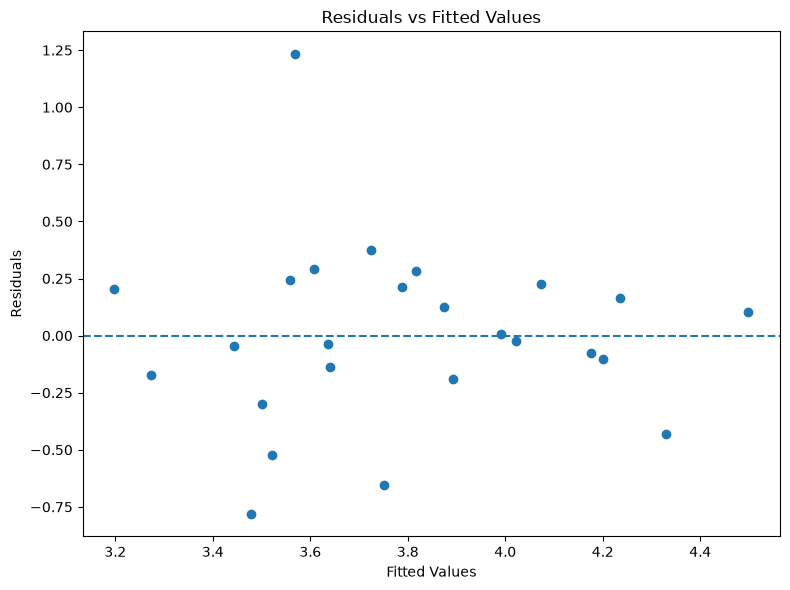

In [53]:
# Residuals vs Fitted Values

import matplotlib.pyplot as plt

# Predicted values

predicted = ols_model.fittedvalues

# Residuals

residuals = ols_model.resid

plt.figure(figsize=(8,6))

plt.scatter(
    predicted,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.title("Residuals vs Fitted Values")

plt.tight_layout()

plt.show()

In [54]:
# Save the figure 

diagnostic_path = (
    FINAL_OUTPUT_DIR /
    "Residuals_vs_Fitted.png"
)

plt.figure(figsize=(8,6))

plt.scatter(
    predicted,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.title("Residuals vs Fitted Values")

plt.tight_layout()

plt.savefig(
    diagnostic_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Residual plot saved.")

Residual plot saved.


<Figure size 700x700 with 0 Axes>

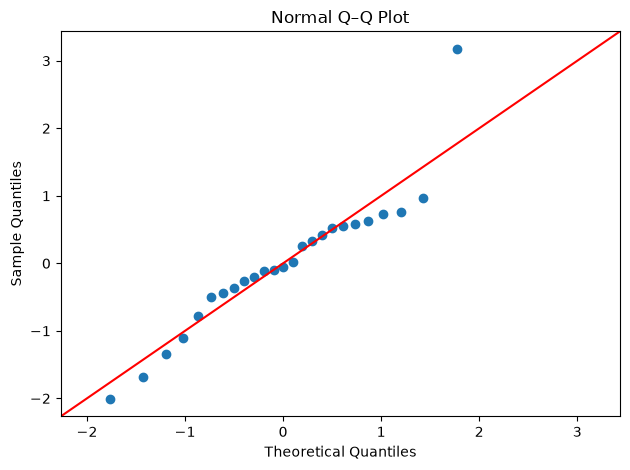

In [55]:
# Normal Q–Q Plot

import statsmodels.api as sm

plt.figure(figsize=(7,7))

sm.qqplot(
    residuals,
    line="45",
    fit=True
)

plt.title("Normal Q–Q Plot")

plt.tight_layout()

plt.show()

In [57]:
# Save the normal Q-Q plot 

qq_path = (
    FINAL_OUTPUT_DIR /
    "QQ_Plot.png"
)

fig = sm.qqplot(
    residuals,
    line="45",
    fit=True
)

plt.title("Normal Q–Q Plot")

plt.tight_layout()

plt.savefig(
    qq_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Q–Q plot saved.")

Q–Q plot saved.


## 7.18 Regression Model Summary

The principal regression statistics are consolidated into a single summary table to facilitate interpretation and reporting within the Results chapter.

In [58]:
model_summary = pd.DataFrame({
    "Statistic": [
        "Number of observations",
        "R-squared",
        "Adjusted R-squared",
        "F-statistic",
        "Model p-value",
        "Durbin-Watson"
    ],
    "Value": [
        int(ols_model.nobs),
        round(ols_model.rsquared, 3),
        round(ols_model.rsquared_adj, 3),
        round(ols_model.fvalue, 3),
        round(ols_model.f_pvalue, 4),
        round(sm.stats.stattools.durbin_watson(ols_model.resid), 3)
    ]
})

display(model_summary)

,Statistic,Value
0,Number of observations,25.0000
1,R-squared,0.4160
2,Adjusted R-squared,0.2990
3,F-statistic,3.5640
4,Model p-value,0.0238
5,Durbin-Watson,1.8120


In [59]:
# Save the regression model summary 

model_summary_path = (
    FINAL_OUTPUT_DIR /
    "Regression_Model_Summary.csv"
)

model_summary.to_csv(
    model_summary_path,
    index=False,
    encoding="utf-8-sig"
)

print("Regression model summary saved.")

Regression model summary saved.
